<h1 style = "color: #2D68C4;"><strong><em><center>College Scorecard Study - Comparing The Characteristics Between UCLA & Other UC Institutions</strong></em></center></h1>

<h2 style = "color: #2D68C4;"><strong><center>Statistical Investigation Question:</strong></center></h2>

<h3 style = "color: #2D68C4;"><center>How do UCLA's and UC Berkeley's middle income median earnings compare to ALL other UC institutions?</center>

<h2 style = "color: #2D68C4;"><strong><center>Type of Statistical Study:</strong></center></h2>

<h3 style = "color: #2D68C4;"><center>I plan to conduct a census study becauase I'll need to use all institutions within the UC system to help answer my question. I will need to compare the median earnings of universities like UC Berkeley, UCLA, UC Santa Barbara, UC Irvine, UC Davis, among others. I have access to the data found on the College Scorecard website, which is maintained by the U.S. Department of Education. It contains data for all post-secondary institutions in the United States, so it is a population-based dataset.</center>

In [21]:
from IPython.core.display import HTML
HTML("""
<style>
    /* Targets JupyterLab, Classic Notebooks, and VS Code workspaces */
    #notebook-container, .jp-Notebook, .jp-Cell, .jp-Notebook-panel {
        background-color: #FFD100 !important;
    }
    
    /* Forces Markdown text and headers to turn white for contrast */
    .rendered_html, .jp-RenderedHTMLCommon, 
    .rendered_html p, .rendered_html h1, .rendered_html h2, .rendered_html h3 {
        color: #ffffff !important;
    }
    
    /* Optional: Tweaks code cell borders so they don't look completely invisible */
    .jp-InputArea-editor, .CodeMirror {
        border: 1px solid rgba(255, 255, 255, 0.2) !important;
    }
</style>
""")


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv("cleaned_college.csv")

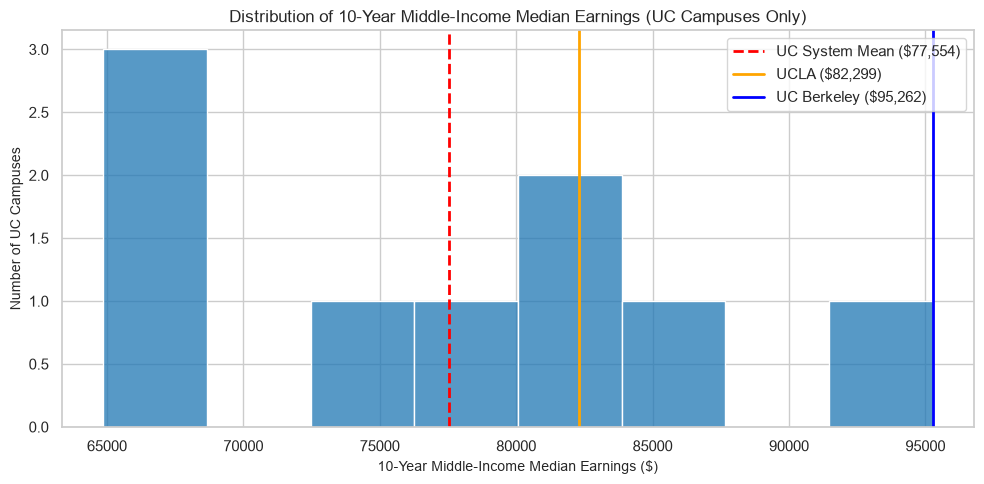

In [24]:
# 1. Filter for ONLY undergraduate UC institutions
uc_df = df[df['school_name'].str.startswith('University of California-')].dropna(subset=['median_earnings_10yrs_middle_income']).copy()

# 2. Create histogram plot
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

sns.histplot(
    data=uc_df, 
    x="median_earnings_10yrs_middle_income", 
    bins=8, 
    color="#1f77b4"
)

# 3. Add vertical reference lines for Mean, UCLA, and UC Berkeley
uc_mean = uc_df['median_earnings_10yrs_middle_income'].mean()
ucla_val = uc_df[uc_df['school_name'] == 'University of California-Los Angeles']['median_earnings_10yrs_middle_income'].item()
cal_val = uc_df[uc_df['school_name'] == 'University of California-Berkeley']['median_earnings_10yrs_middle_income'].item()

plt.axvline(uc_mean, color='red', linestyle='--', linewidth=2, label=f'UC System Mean (${uc_mean:,.0f})')
plt.axvline(ucla_val, color='orange', linestyle='-', linewidth=2, label=f'UCLA (${ucla_val:,.0f})')
plt.axvline(cal_val, color='blue', linestyle='-', linewidth=2, label=f'UC Berkeley (${cal_val:,.0f})')

# 4. Format labels and legend
plt.title("Distribution of 10-Year Middle-Income Median Earnings (UC Campuses Only)", fontsize=12)
plt.xlabel("10-Year Middle-Income Median Earnings ($)", fontsize=10)
plt.ylabel("Number of UC Campuses", fontsize=10)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [25]:
# 1. Filter the dataset for ONLY undergraduate UC campuses
uc_df = df[df['school_name'].str.startswith('University of California-')].dropna(subset=['median_earnings_10yrs_middle_income'])

# 2. Calculate summary statistics for the UC System only
mean_uc_middle_income = uc_df["median_earnings_10yrs_middle_income"].mean()
median_uc_middle_income = uc_df["median_earnings_10yrs_middle_income"].median()
std_uc_middle_income = uc_df["median_earnings_10yrs_middle_income"].std()

# 3. Print the results
print("UC System Mean:", mean_uc_middle_income)
print("UC System Median:", median_uc_middle_income)
print("UC System Standard Deviation:", std_uc_middle_income)

UC System Mean: 77554.11111111111
UC System Median: 78792.0
UC System Standard Deviation: 10025.54204824413


In [26]:
ucla = df[df["school_name"] == "University of California-Los Angeles"]
ucla_middle_income_median_earnings = ucla["median_earnings_10yrs_middle_income"].item()
print(ucla_middle_income_median_earnings)

82299.0


In [27]:
cal = df[df["school_name"] == "University of California-Berkeley"]
cal_middle_income_median_earnings = cal["median_earnings_10yrs_middle_income"].item()
print(cal_middle_income_median_earnings)

95262.0


In [28]:
# 1. Filter dataset for ONLY undergraduate UC institutions
uc_df = df[df['school_name'].str.startswith('University of California-')].dropna(subset=['median_earnings_10yrs_middle_income']).copy()

# 2. Extract median earnings for UCLA and UC Berkeley
ucla_middle_income_median_earnings = uc_df[uc_df['school_name'] == 'University of California-Los Angeles']['median_earnings_10yrs_middle_income'].item()
cal_middle_income_median_earnings = uc_df[uc_df['school_name'] == 'University of California-Berkeley']['median_earnings_10yrs_middle_income'].item()

# 3. Calculate mean and standard deviation for UC institutions ONLY
mean_middle_income_median_earnings = uc_df["median_earnings_10yrs_middle_income"].mean()
std_middle_income_median_earnings = uc_df["median_earnings_10yrs_middle_income"].std()

# 4. Calculate Z-scores relative to the UC System
z_ucla = (ucla_middle_income_median_earnings - mean_middle_income_median_earnings) / std_middle_income_median_earnings
z_cal = (cal_middle_income_median_earnings - mean_middle_income_median_earnings) / std_middle_income_median_earnings

print("UCLA Z-score (UC Only):", z_ucla)
print("UC Berkeley Z-score (UC Only):", z_cal)

UCLA Z-score (UC Only): 0.4732800347408556
UC Berkeley Z-score (UC Only): 1.7662774544933701


In [29]:
# Standard deviation of UC middle-income median earnings
std_uc = uc_df["median_earnings_10yrs_middle_income"].std()
print("UC Standard Deviation:", std_uc)

UC Standard Deviation: 10025.54204824413


<h2 style = "color: #2D68C4;"><strong><center>Analysis of Data:</strong></center></h2>

<h3 style = "color: #2D68C4;"><center>When reflecting on the median earnings of all UC institutions, UCLA and UC Berkeley are both pretty high, at \$82,299 and \$95,262, respectively. According to the histogram shown above, the UC system mean is at \$77,554, signifying that both UC schools have higher year middle income earnings than that value. UC Merced has the lowest median earnings whereas UC Berkeley leads the way. The standard deviation of ALL UC schools is approximately \$10,025.54. UCLA's ten year middle income earnings are about 0.47 standard deviations away. On the other hand, Cal is approximately 1.77 standard deviations away from the mean.</center>

<h2 style = "color: #2D68C4;"><strong><center>Conclusion:</strong></center></h2>

<h3 style = "color: #2D68C4;"><center>In summary, UCLA and UC Berkeley students eventually DO make a sufficient amount of money in terms of median earnings per median income for a set of 10 years after graduation.</center>